In [52]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [53]:
df=pd.read_csv("../docs/newDocs/csv/Housing.csv",na_values=['-','NA','/','',' ','null'])

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [55]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [56]:

df=df[df['area']<10000]

In [57]:
df.isna().sum()#vidimo da dataset nema nijednu Na vrednost da je ima Na vrednost odradili bi shapiro wilk test za te kolone koje ima NA vrednosti i te vrednosti zamenili sa medianom ako nemaju Normalnu raspodelu , a ako imaju sa Mean

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [58]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 527 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             527 non-null    int64 
 1   area              527 non-null    int64 
 2   bedrooms          527 non-null    int64 
 3   bathrooms         527 non-null    int64 
 4   stories           527 non-null    int64 
 5   mainroad          527 non-null    object
 6   guestroom         527 non-null    object
 7   basement          527 non-null    object
 8   hotwaterheating   527 non-null    object
 9   airconditioning   527 non-null    object
 10  parking           527 non-null    int64 
 11  prefarea          527 non-null    object
 12  furnishingstatus  527 non-null    object
dtypes: int64(6), object(7)
memory usage: 57.6+ KB


In [59]:
df['mainroad']=df['mainroad'].map({'yes':1,'no':0})

In [60]:
df['guestroom']=df['guestroom'].map({'yes':1,'no':0})

In [61]:
#df['basement']=df['basement'].map({'yes':1,'no':0})

In [62]:
df['hotwaterheating']=df['hotwaterheating'].map({'yes':1,'no':0})

In [63]:
df['airconditioning']=df['airconditioning'].map({'yes':1,'no':0})

In [64]:
df['prefarea']=df['prefarea'].map({'yes':1,'no':0})

In [69]:
df['basement']=df['basement'].map({'yes':1,'no':0})

In [65]:
df['basement'].value_counts()

basement
no     342
yes    185
Name: count, dtype: int64

In [66]:
df['furnishingstatus']=df['furnishingstatus'].map({'semi-furnished':0.5,'unfurnished':0,'furnished':1})

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 527 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             527 non-null    int64  
 1   area              527 non-null    int64  
 2   bedrooms          527 non-null    int64  
 3   bathrooms         527 non-null    int64  
 4   stories           527 non-null    int64  
 5   mainroad          527 non-null    int64  
 6   guestroom         527 non-null    int64  
 7   basement          527 non-null    int64  
 8   hotwaterheating   527 non-null    int64  
 9   airconditioning   527 non-null    int64  
 10  parking           527 non-null    int64  
 11  prefarea          527 non-null    int64  
 12  furnishingstatus  527 non-null    float64
dtypes: float64(1), int64(12)
memory usage: 57.6 KB


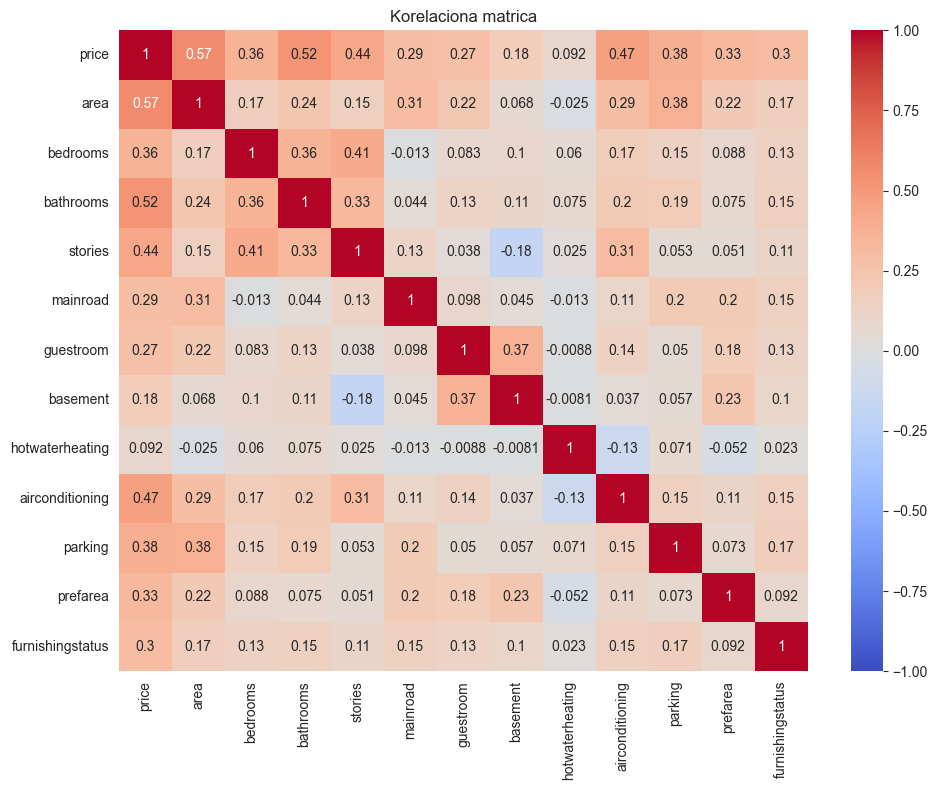

In [71]:
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [ ]:
#sada kada smo sve kolone mapirali na numericke mozemo da uradimo korelacionu matricu
#target nam je price:
# na osnovu korelacije i praga da je sve preko 50% korelacije , znacajno za neki prediktor nasi prediktori za price+ su :
#area sa korelaciojom 0.57
#bathrooms sa korelacijom 0.52

In [73]:
#ostali atributi su izostavljeni jer su u slaboj korelaciji sa cenom
target="price"
predictors=["area","bathrooms"]



In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 527 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             527 non-null    int64  
 1   area              527 non-null    int64  
 2   bedrooms          527 non-null    int64  
 3   bathrooms         527 non-null    int64  
 4   stories           527 non-null    int64  
 5   mainroad          527 non-null    int64  
 6   guestroom         527 non-null    int64  
 7   basement          527 non-null    int64  
 8   hotwaterheating   527 non-null    int64  
 9   airconditioning   527 non-null    int64  
 10  parking           527 non-null    int64  
 11  prefarea          527 non-null    int64  
 12  furnishingstatus  527 non-null    float64
dtypes: float64(1), int64(12)
memory usage: 57.6 KB


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df,test_size=0.2, random_state=42,stratify=pd.qcut(df['price'],q=10,duplicates='drop'))

In [81]:
import statsmodels.formula.api as smf
lm1=smf.ols(formula="price~ area + bathrooms",data=X_train)

In [82]:
lm1=lm1.fit()

In [84]:
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     220.4
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           4.43e-66
Time:                        22:16:49   Log-Likelihood:                -6512.1
No. Observations:                 421   AIC:                         1.303e+04
Df Residuals:                     418   BIC:                         1.304e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.532e+05   2.17e+05      1.631      0.1

In [86]:
#Na osnovu summary modela linearne regresije vidimo da je target varijabla bila price, nad 421 obzervacijom , ovaj model preko R-Squared metrika modela objasnjava 51% varijabilnosti targeta preko nasa 2 targeta.To znaci da ostalih 49% varijabilnosti targeta je objsanjeno ostalim kolonama ili drugim stvarima koje ova skup podataka nije zabelezio ...
#F statistika je 220, a verovatnca F statistike je 4.43 na 10^-66 sto je skoro nula cime se ponistava nulta hipoteza H0 da smo slucajno dobili ove rezultate i to znaci da je model znacajan ...

In [ ]:
# Koeficijenti prediktora su za area kolonu 489 sto znaci da sa povecanjem jedne jedinice vr area nasa cena se poveca za 489 kada drugi prediktor ostane isti .
# Koeficijenti prediktora  za bathrooms kolonu 1.525 * 10^6 znaci da sa povecanjem jedne jedinice vr bathrooms nasa cena se poveca za 1.525 * 10^6 kada drugi prediktor ostane isti .

# vr intercepta je 3.532 * 10^5  sto oznacava osnovnu vr price tareta kada su prediktori 0.
# vidimo da je  p statistika za koeficijente prediktora 0 sto znaci da su oba prediktora znacajni , p<0.05.... zadovoljeno ...
# takodje treba obratiti paznju na cond number koji je veliki , to mozda oznacava da postoji velika multikolinearnost izmedju prediktora provericemo kasnije sa VIFom.


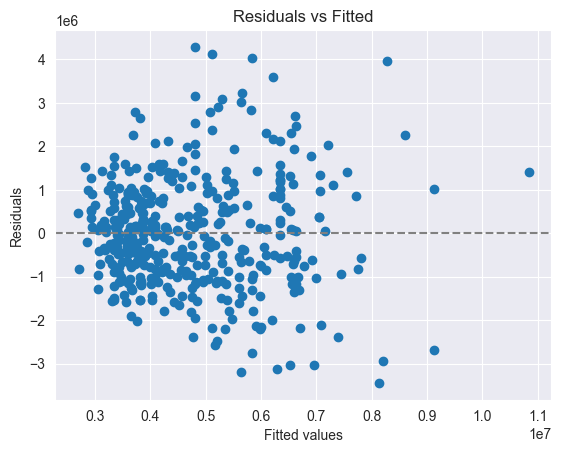

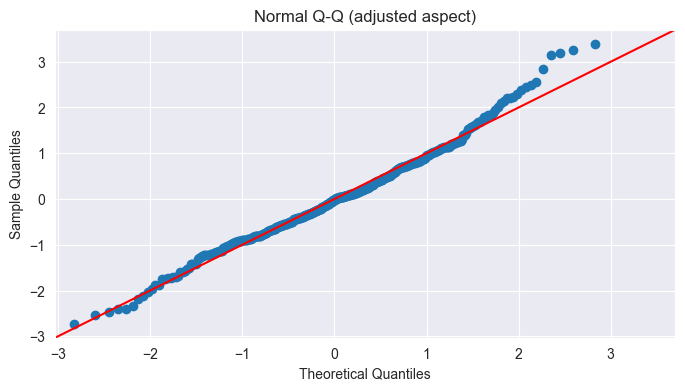

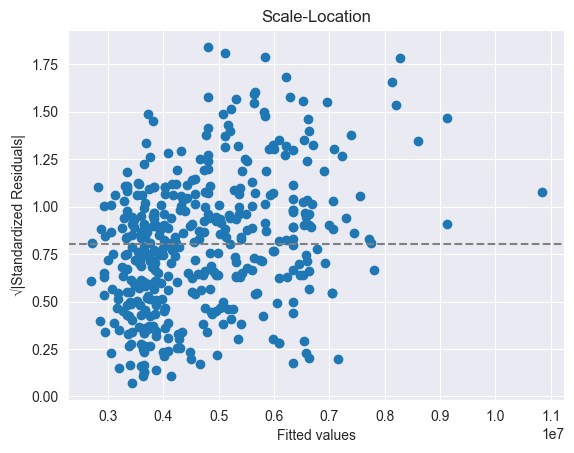

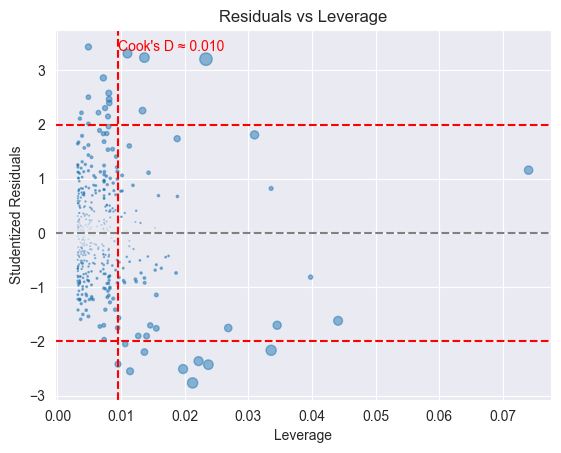

In [87]:
 #Grafici
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
# Residuals vs Fitted
plt.scatter(lm1.fittedvalues, lm1.resid)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()
# Normal Q-Q (širi graf da linija deluje blaže)
sm.qqplot(lm1.resid, line='45', fit=True)
plt.gcf().set_size_inches(8, 4)
plt.title("Normal Q-Q (adjusted aspect)")
plt.show()
# Scale-Location
influence = lm1.get_influence()
std_resid = influence.resid_studentized_internal
abs_sqrt_resid = np.sqrt(np.abs(std_resid))
plt.scatter(lm1.fittedvalues, abs_sqrt_resid)
plt.axhline(np.mean(abs_sqrt_resid), color='gray', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("√|Standardized Residuals|")
plt.title("Scale-Location")
plt.show()
# Residuals vs Leverage + Cook's D threshold
leverage = influence.hat_matrix_diag
stud_resid = influence.resid_studentized_external
cooks_d = influence.cooks_distance[0]
n = len(lm1.model.endog)
thresh = 4 / n

plt.scatter(leverage, stud_resid, s=1000 * cooks_d, alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.axvline(thresh, color='red', linestyle='--')
plt.text(thresh, plt.ylim()[1]*0.9, f"Cook's D ≈ {thresh:.3f}", color='red')
plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")
plt.title("Residuals vs Leverage")
plt.show()

In [ ]:
 #Grafik 1:  # Residuals vs Fitted pokazuje odnos reziduala  i predvidjenih tj fitted vrednosti naseg modela. Reziduali su razlika izmedju stvarnih vrednosti kolone price i nase predikcije za tu obzervaciju. Graf predstvalja kako su rasporedjeni rezudiali oko krive y=0 gde je i u teorijsko savrsenom slucaju najbolje da reziduali i budu na tome to znaci da model ne pravi greske Naravno to nije moguce . Vidimo da nas model Otrpilike dobro predvidja niske cena kuca , ali kako vrednost fitted raste sto znaci da raste cena kuca tako sve vise vidimo da su reziduali veci i da gresimo .. Na grafu nema nikakvih pravila, problematicnih krivi ili nesto sto pokazuje da je model ne linearan .

In [88]:
#Grafik 2 : Normal Q-Q prikazuje reziduale i kako se oni predstvlajju u odnosu na normalnu raspodelu koja je na slici predstljvanje crvenom dijagonalnom linijom . Model odlicno prati tu krivu , samo postoje odstupanja na krajevima to su bas one situacije kada je kuca previse skupa i ne mozemo da predvidimo tacnu cenu , mozda osrednja  kuca ali od nekog poznatog pa je zato skupa ... Mozemo da zakljucimo da zbog reziduala na kraju nemmao normalnu raspodelu

In [ ]:
# Grafik 3 pokazuje dosta slicnu situaciju kao i grafik 1 samo sada vidimo standardizovane tj studentizovane reziduale na osnovu Studentove raspodele , mozemo da uocimo heteroskedasticnost.

In [90]:
#Grafik 4: Residuali vs Leverage. Ovaj graf pokazuje Cookovu distancu koja se racuna na osnovu reziduala i leveraga. Imamo 4 dela ovog grafa dole levo : sto predstvalja male reziduale i mali leverage ovo znaci da nismo pogresili neku obicnu obzervaciju ... u nasem slucaju vecina obzervacija je ovde i vidimo najvecu kolocinu malih tackica u tom delu kao i u sredini .

In [91]:
#dole desno : Ovo prikazuje  situacije kada smo malo pogresili na ne nekim neobicnim Tackama kada je Levaerge veliki vidimo da nema takvih situacija ...
#Levo gore : ovo je situacija kada smo dosa pogresili na obicinim tackama : u nasoj situaciji postoji dosta ovakvih situaicja..

In [ ]:
#i Desno Gore ovo je najuticijana situacija : gde je Leverage velik i dosta smo pogresili .. Vidimo da ne postoji dosta takvih tacaka
# u slucaju da je postajala neka velika tacka u ovom grafikonu sto je veca tacka, povlaci ideju da njeno izbacivanje iz modela ce da dosta promeni pravu linearne regresije bas ovo moeri Cookova distanca i ove crvene linije.

In [92]:
X_train_predictors=pd.DataFrame;

In [94]:
X_train_predictors=X_train[['area','bathrooms']]

In [95]:
X_train_predictors

,area,bathrooms
104,5500,2
244,5320,1
38,6000,1
364,3120,1
182,3410,1
...,...,...
22,8050,1
407,2145,1
400,3512,1
1,8960,4


In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import statsmodels.api as sm
import pandas as pd

# Pripremamo X: svi prediktori iz train_df + konstanta.
X = sm.add_constant(X_train_predictors)
# Računamo VIF za svaki prediktor i vadimo kvadratni koren (√VIF)
# √VIF iznad 2 - potencijalna kolinearnost (prag po izboru)
print("√VIF sa svim prediktorima:")
print((pd.Series([vif(X.values, i) for i in range(X.shape[1])],
                 index=X.columns) ** 0.5).sort_values(ascending=False))


√VIF sa svim prediktorima:
const        3.506246
area         1.045128
bathrooms    1.045128
dtype: float64


In [ ]:
#vidimo da Vif nije iznad 2 za ove 2 kolone i ne postoji kolinearnost.